In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import math
import trimesh
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
torch.manual_seed(42)

In [6]:
data = np.load('data_lunar_mesh_ex.npy', allow_pickle=True)
print(data.shape)

lidar = np.array(data[:,:, 10:], dtype=np.float32)

# making sure that correctly reading lidar
print(lidar.shape)
lidar = lidar.reshape(lidar.shape[0], lidar.shape[1], int(lidar.shape[2]/3), 3)
print(lidar.shape)
print(lidar[5][0])

(889, 19, 310)
(889, 19, 300)
(889, 19, 100, 3)
[[inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf inf inf]
 [inf i

(16891,)


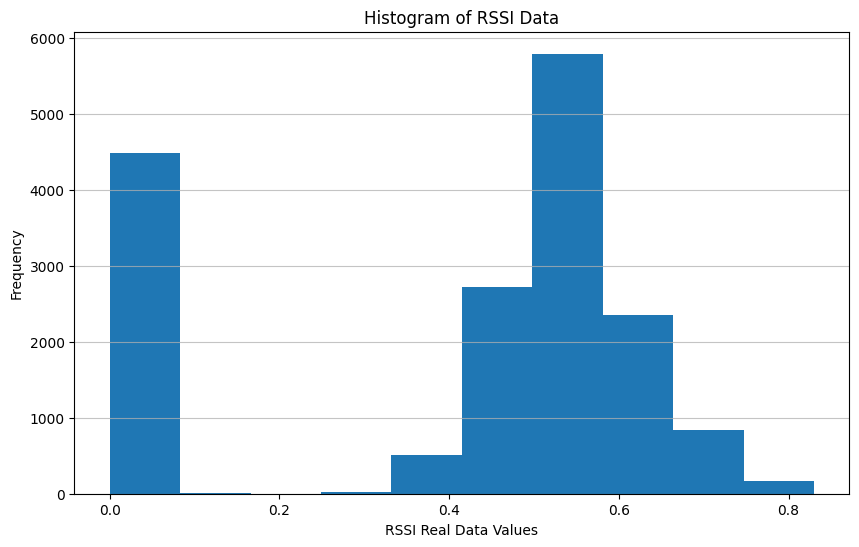

In [2]:

rsi_real = data[:, :, 0].flatten()
print(rsi_real.shape)

# Compute the histogram
hist, bin_edges = np.histogram(rsi_real, bins=10)

# Plot the histogram using bar
plt.figure(figsize=(10, 6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist, width=np.diff(bin_edges), align='center')
plt.title('Histogram of RSSI Data')
plt.xlabel('RSSI Real Data Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [194]:
## Converting lidar to range data
#HAVE TO TRY RUNNING THIS ON UNNORMALIZED LIDAR DATA
print(data.shape)

count = 0

def normalize_range(x, minx=0, maxx=100):
    return (x - minx) / (maxx - minx)

def distance(x, y):
    dist = (x[0]-y[0])**2 + (x[1]-y[1])**2 + (x[2]-y[2])**2
    if math.isinf(dist):
       return 100

    global count 
    count += 1
    # print(math.sqrt(dist))
    return math.sqrt(dist)

def getRange(position, lidar):
    range_data = []
    for i in range(len(lidar)):
        dist = normalize_range(distance(position, lidar[i]))
        range_data.append(dist)
        
    return np.array(range_data)

lidar_range = np.empty((0, 100))
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        position = [data[i, j, 7], data[i, j, 8], data[i, j, 9]]
        range_data = getRange(position, data[i, j, 10:].reshape(100, 3)).reshape(1, -1)
        lidar_range = np.concatenate((lidar_range, range_data), axis=0)

lidar_range = lidar_range.reshape(data.shape[0], data.shape[1], -1)
print("Num seen " + str(count))

(889, 19, 310)
Num seen 4839


(889, 19, 100)
0.9973228387809125


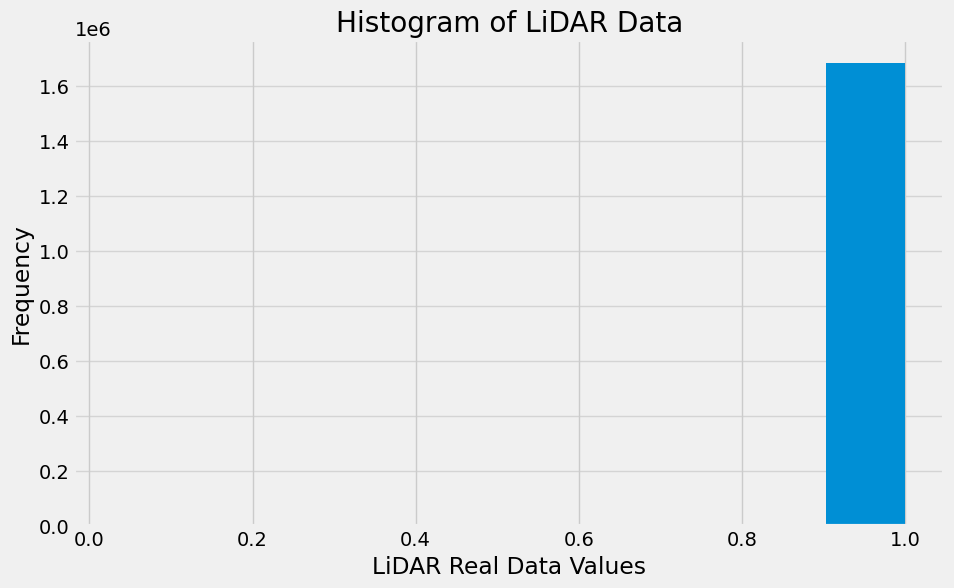

In [174]:
print(lidar_range.shape) # 889, 19, 100
print(np.mean(lidar_range.flatten()))

# Compute the histogram
hist, bin_edges = np.histogram(lidar_range.flatten(), bins=10)

# Plot the histogram using bar
plt.figure(figsize=(10, 6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist, width=np.diff(bin_edges), align='center')
plt.title('Histogram of LiDAR Data')
plt.xlabel('LiDAR Real Data Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [175]:
print(lidar_range.shape)
print(lidar_range[100][0])
# print(lidar[1][0])
# print(lidar_range[1])

(889, 19, 100)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


In [176]:
# SIMPLE LIDAR MODEL THAT USES LIDAR RANGE DATA
#https://medium.com/we-talk-data/pytorchs-sequential-3974f27c714e 

# print(lidar_range[1][0])
lidar_range = lidar_range.reshape(-1, 100)
print(lidar_range.shape)

dataset = torch.tensor(lidar_range, dtype=torch.float32)
print(dataset.shape)

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

(16891, 100)
torch.Size([16891, 100])


In [143]:
class FCN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_sizes
        self.output_size = output_size
        
        self.steps = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], output_size)
        )

    def forward(self, x):
        x = self.steps(x)
        return x

num_epochs = 1000
model_lidar_range = FCN(input_size = 100, hidden_sizes=[100, 100], output_size=100)
optimizer = torch.optim.Adam(model_lidar_range.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(num_epochs):
    model_lidar_range.train()
    for input_seq in train_loader:
        input_seq = input_seq[:, :100]
        input_seq = torch.nan_to_num(input_seq, nan=1e-6, posinf=1e-6, neginf=1e-6)

        output = model_lidar_range(input_seq)
        target_val = input_seq

        loss = criterion(output, target_val)  # shape: [batch, 100]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [144]:
print(lidar_range[20])
model_lidar_range(torch.tensor(lidar_range[20], dtype=torch.float32))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


tensor([0.9998, 1.0006, 1.0011, 0.9992, 0.9989, 0.9980, 0.9981, 0.9976, 0.9990,
        0.9989, 0.9979, 0.9981, 0.9970, 0.9985, 0.9986, 0.9984, 0.9963, 0.9981,
        0.9978, 0.9979, 1.0003, 1.0000, 0.9977, 0.9969, 0.9954, 0.9962, 0.9991,
        1.0003, 1.0031, 0.9997, 0.9982, 0.9976, 0.9989, 0.9990, 1.0030, 0.9986,
        0.9982, 1.0003, 1.0029, 1.0016, 1.0018, 1.0022, 1.0019, 1.0023, 0.9979,
        0.9979, 0.9981, 1.0005, 1.0022, 0.9997, 0.9986, 0.9998, 1.0008, 0.9992,
        0.9998, 0.9999, 0.9990, 1.0001, 0.9982, 0.9976, 0.9992, 0.9989, 0.9980,
        1.0007, 1.0007, 1.0005, 0.9991, 0.9972, 0.9959, 0.9985, 0.9989, 0.9989,
        0.9993, 0.9991, 0.9996, 0.9995, 0.9996, 0.9995, 0.9993, 0.9981, 0.9992,
        0.9996, 0.9971, 0.9985, 0.9977, 0.9989, 0.9997, 0.9995, 0.9997, 0.9996,
        0.9995, 1.0004, 0.9992, 0.9984, 1.0001, 1.0000, 0.9998, 0.9983, 0.9983,
        0.9998], grad_fn=<ViewBackward0>)

In [152]:
## Autoencoder, compression
# https://www.geeksforgeeks.org/auto-encoders/

dataset = torch.tensor(lidar_range, dtype=torch.float32)
dataset = dataset.reshape(-1, 19, 100)
print(dataset.shape)

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

class AutoEncoderRange(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(AutoEncoderRange, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_sizes
        self.output_size = output_size
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], output_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(output_size, hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], input_size),
        )
    
    def forward(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return encoded, decoded



torch.Size([889, 19, 100])


Epoch 100/500, Loss: 0.001539
Epoch 200/500, Loss: 0.001057
Epoch 300/500, Loss: 0.000000
Epoch 400/500, Loss: 0.000002
Epoch 500/500, Loss: 0.000000


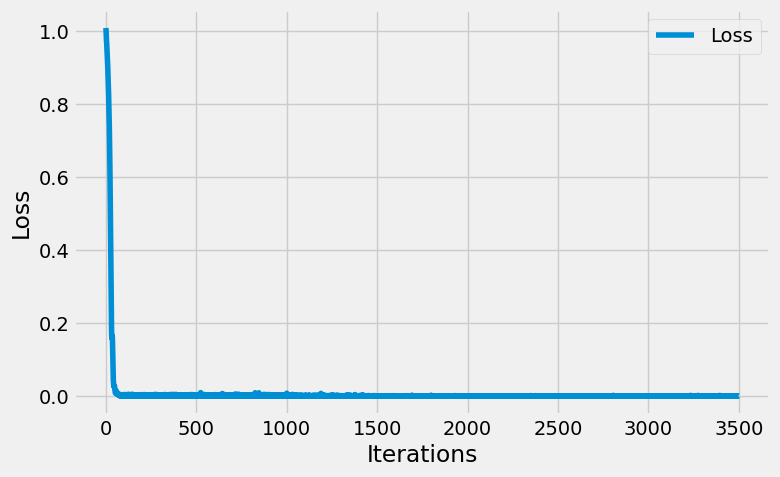

In [153]:
num_epochs = 500
model_lidar_range_encoder = AutoEncoderRange(input_size = 100, hidden_sizes=[50, 25], output_size=5)
optimizer = torch.optim.Adam(model_lidar_range_encoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

outputs = []
losses = []

for epoch in range(num_epochs):
    model_lidar_range_encoder.train()
        
    for input_seq in train_loader:
        input_seq = input_seq[:, :100]
        input_seq = torch.nan_to_num(input_seq, nan=1e-6, posinf=1e-6, neginf=1e-6)

        encoded, decoded = model_lidar_range_encoder(input_seq)
        target_val = input_seq

        loss = criterion(decoded, target_val)  # shape: [batch, 100]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
         
        
        losses.append(loss.item())
    
    # outputs.append((epoch, images, reconstructed))
    if ((epoch + 1) % 100) == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [231]:
### conver lidar frame from gloabl ref to relative reference

lidar = np.empty((0, 300))
for i in range(data.shape[0]):
    print(i)
    for j in range(data.shape[1]):
        position = [data[i, j, 7], data[i, j, 8], data[i, j, 9]]*100
        position = np.array(position).reshape(100, 3)
        # print(position)
        lidar_data = data[i, j, 10:]
        lidar_data = lidar_data.reshape(100, 3)
        lidar_data = lidar_data - position
        for k in range(len(lidar_data)):
            if (math.isinf(lidar_data[k][0])):
                lidar_data[k][0] = 0
                lidar_data[k][1] = 0
                lidar_data[k][2] = 0
        lidar = np.concatenate((lidar, lidar_data.reshape(1, 300)), axis=0)

print(lidar)
lidar = np.array(lidar, dtype=np.float32)
print(lidar.shape)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [232]:
### encode actual lidar data

## Autoencoder, compression
# https://www.geeksforgeeks.org/auto-encoders/

dataset = torch.tensor(lidar, dtype=torch.float32)
dataset = dataset.reshape(-1, 19, 300)
print(dataset.shape)

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

class AutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(AutoEncoder, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_sizes
        self.output_size = output_size
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], output_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(output_size, hidden_sizes[1]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[1], hidden_sizes[0]),
            nn.ReLU(), # Activation layer
            nn.Linear(hidden_sizes[0], input_size),
        )
    
    def forward(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return encoded, decoded



torch.Size([889, 19, 300])


Epoch 100/500, Loss: 0.001777
Epoch 200/500, Loss: 0.000615
Epoch 300/500, Loss: 0.001126
Epoch 400/500, Loss: 0.000001
Epoch 500/500, Loss: 0.000855


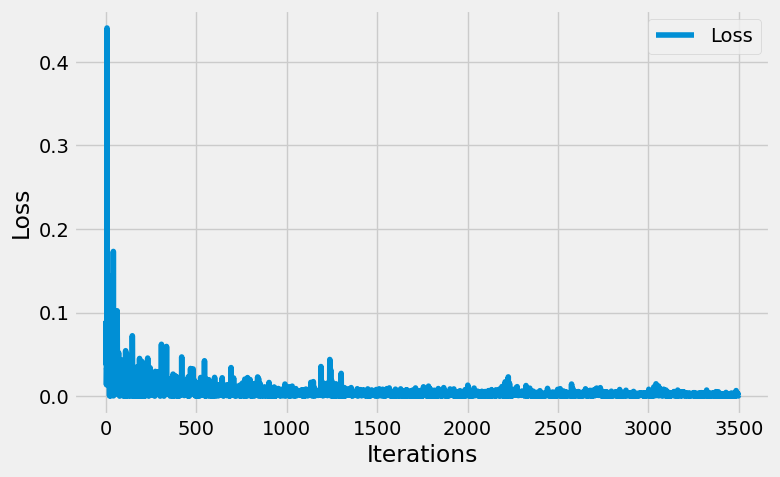

In [233]:
num_epochs = 500
model_lidar_encoder = AutoEncoder(input_size = 300, hidden_sizes=[100, 50], output_size=25)
optimizer = torch.optim.Adam(model_lidar_encoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

outputs = []
losses = []

for epoch in range(num_epochs):
    model_lidar_encoder.train()
        
    for input_seq in train_loader:
        input_seq = input_seq[:, :300]
        input_seq = torch.nan_to_num(input_seq, nan=1e-6, posinf=1e-6, neginf=1e-6)

        encoded, decoded = model_lidar_encoder(input_seq)
        target_val = input_seq

        loss = criterion(decoded, target_val)  # shape: [batch, 100]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
         
        
        losses.append(loss.item())
    
    # outputs.append((epoch, images, reconstructed))
    if ((epoch + 1) % 100) == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
### Test on actual model
# -----------------------------------------------------------------------------------------------------------------------------------------

In [13]:
num_epochs = 100

data = np.load("data_lunar_mesh_ex.npy", allow_pickle=True)
data = data.astype(np.float32)
print(f"Loaded data shape: {data.shape}")

total_traj = data.shape[0]
seq_len = data.shape[1] + 1


data = torch.tensor(data[:,:, :10].reshape(total_traj * (seq_len - 1), 10), dtype=torch.float32)
combined_data = data.reshape(total_traj, seq_len - 1, 10)
print(combined_data.shape)

# print(data.shape)
# lidar_data = model_lidar_range(torch.tensor(lidar_range, dtype=torch.float32))
# # lidar_data, decoded = model_lidar_range_encoder(torch.tensor(lidar_range, dtype=torch.float32))
# lidar_data, decoded = model_lidar_encoder(torch.tensor(lidar.reshape(total_traj, seq_len - 1, 300)))

# test models
# combined_data = torch.cat((combined_data, lidar_data.detach().reshape(total_traj, (seq_len - 1), -1)), axis=2)
# unchanged lidar data
# combined_data = torch.cat((combined_data, torch.tensor(lidar.reshape(total_traj, seq_len - 1, 300))), axis=2)
# without above line, OG model W/O lidar
combined_data.shape

Loaded data shape: (889, 19, 310)
torch.Size([889, 19, 10])


torch.Size([889, 19, 10])

In [18]:
# total_traj = 500
# seq_len = 20
# data = np.load("data_lunar_mesh_ex.npy")
# print(f"Loaded data shape: {data.shape}")
# data = data[:,:, :10].reshape(total_traj, seq_len - 1, 10) 

class TrajectoryDataset(torch.utils.data.Dataset):
    def __init__(self, data_tensor, predictions):
        self.data = data_tensor
        self.predictions = predictions

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        seq = self.data[idx]                 # shape (21, 10)
        # print(seq.shape[0])
        # print(seq.shape[0] - self.predictions)
        input_seq = seq[:seq.shape[0] - self.predictions]                 # shape (18, 10)
        target_values = seq[seq.shape[0] - self.predictions:]          # shape (3,) — 3 future values of feature[0]
        return input_seq, target_values

num_pred = 10
input_size = combined_data.shape[2]

# Wrap your tensor in the dataset
dataset = TrajectoryDataset(combined_data, num_pred)

# Split
train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

class LSTMMultiStep(nn.Module):
    def __init__(self, input_size=input_size, hidden_size=64, num_layers=1, num_pred=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_pred)  # Predict 3 future values (1 feature)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        last_hidden = hn[-1]                 # shape: (batch, hidden_size)
        output = self.fc(last_hidden)        # shape: (batch, 3)
        output = self.activation(output)
        return output

print(dataset.data.shape)
input_seq, target_values = dataset.__getitem__(0)
print(input_seq.shape)
# print(dataset.__getitem__(0)[1].shape)


torch.Size([889, 19, 10])
torch.Size([9, 10])


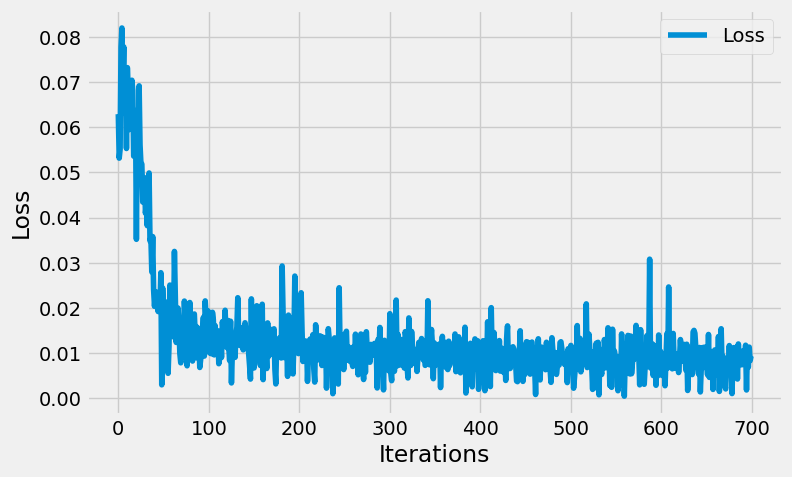

In [19]:
model = LSTMMultiStep(input_size=input_size-3, num_pred=num_pred)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []

for epoch in range(num_epochs):
    model.train()
    for input_seq, target_val in train_loader:
        input_seq = torch.concatenate((input_seq[:, :, :7], input_seq[:, :, 10:]), axis=2)
        output = model(input_seq)
        loss = criterion(output, target_val[:,:,0]) # Add PINNs stuff here
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    # Optional test loop
    rssi_ground_truth = []
    rssi_predicted = []
    pos = []
    rssi_seq = []
    model.eval()
    with torch.no_grad():
        test_losses = []
        for input_seq, target_val in test_loader:
            # pos.append(input_seq[:, -1, 7:])
            pos.append(target_val[:,:,7:10])
            input_seq = torch.concatenate((input_seq[:, :, :7], input_seq[:, :, 10:]), axis=2)
            test_output = model(input_seq)
            rssi_ground_truth.append(target_val[:,:,0].numpy())
            rssi_seq.append(np.concatenate([input_seq.numpy()[:, :, 0], target_val[:,:,0].numpy()], axis=1))
            rssi_predicted.append(test_output.numpy())
            test_loss = criterion(test_output, target_val[:,:,0])
            test_losses.append(test_loss.item())
        avg_test_loss = sum(test_losses) / len(test_losses)


torch.save(model.state_dict(), "NASA_DCGR.pt")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [20]:
mesh = trimesh.load_mesh("models/lunar_mesh_ex.ply")
# mesh = trimesh.load_mesh("models/canyon.ply")

print(len(rssi_seq))
rssi_seq_start = np.array(rssi_seq[0])
print(rssi_seq_start[:,:9].shape)

# Naive prediction
naive_pred = rssi_seq_start[:, 8:9].repeat(10, 1)
print(naive_pred.shape)

# Linear regression
x_fit = np.arange(9)
x_pred = np.arange(9, 19)

# Fit degree-1 polynomial (line)
coeffs = np.polyfit(x_fit, rssi_seq_start[:, :9].T, deg=1)  # shape (2, 995)

# Evaluate line at x_pred
x_pred_powers = np.vstack([x_pred, np.ones_like(x_pred)])  # shape (2, 10)
linear_pred = coeffs.T @ x_pred_powers  # shape (995, 10)
print(linear_pred.shape)

# Cubic spline
from scipy.interpolate import CubicSpline
spline_preds = []

for seq in rssi_seq_start[:, :9]:
    cs = CubicSpline(x_fit, seq[:9], extrapolate=True)
    pred = cs(x_pred)
    spline_preds.append(pred)

spline_pred = np.stack(spline_preds)  # shape (995, 10)
print(spline_pred.shape)

# radius = 5.0  # small radius for visibility
# markers = []
# for rssis, poses in zip(predictions, pos[0]):
#     for rssi, pose in zip(rssis, poses):
#         marker = trimesh.creation.icosphere(radius=radius, color=[rssi, 0, (1 - rssi), 1])  # red color
#         marker.apply_translation(pose)
#         markers.append(marker)

# scene = trimesh.Scene()
# scene.add_geometry(markers)
# scene.add_geometry(mesh)
# scene.show()

2
(200, 9)
(200, 10)
(200, 10)
(200, 10)


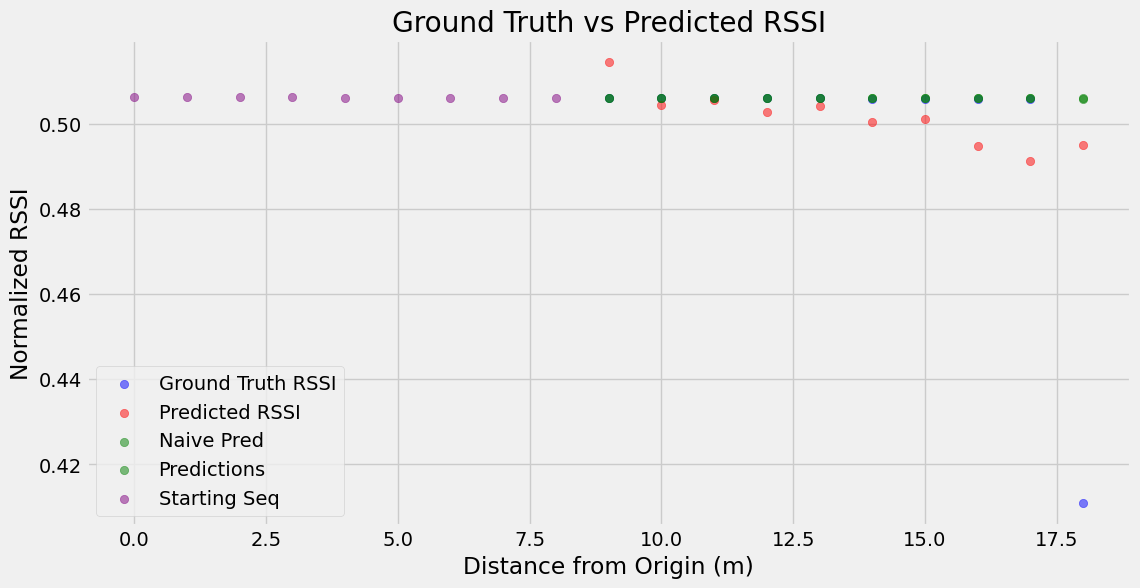

RNN Predictions
Mean Squared Error (MSE): 0.0064
Mean Absolute Error (MAE): 0.0357
Linear Regression Predictions
Mean Squared Error (MSE): 0.0118
Mean Absolute Error (MAE): 0.0306
torch.Size([2000, 3])
(2000,)


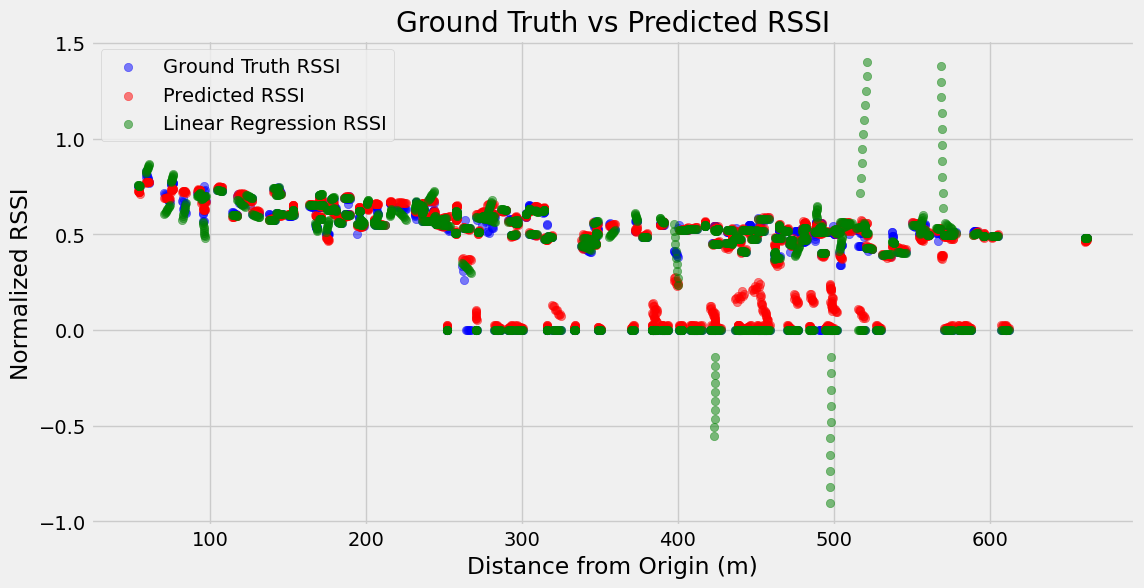

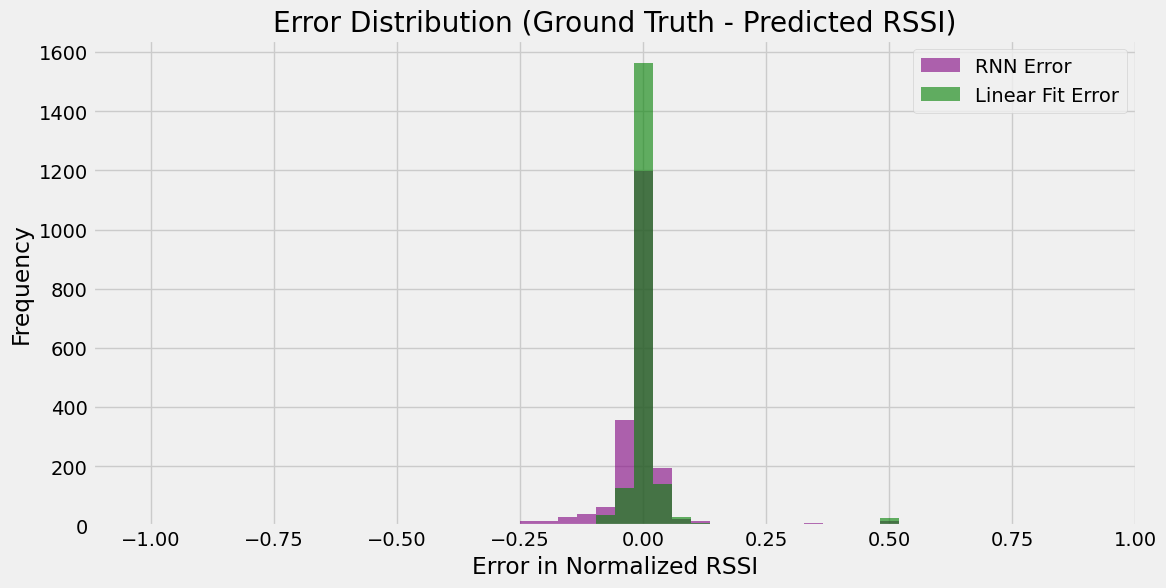

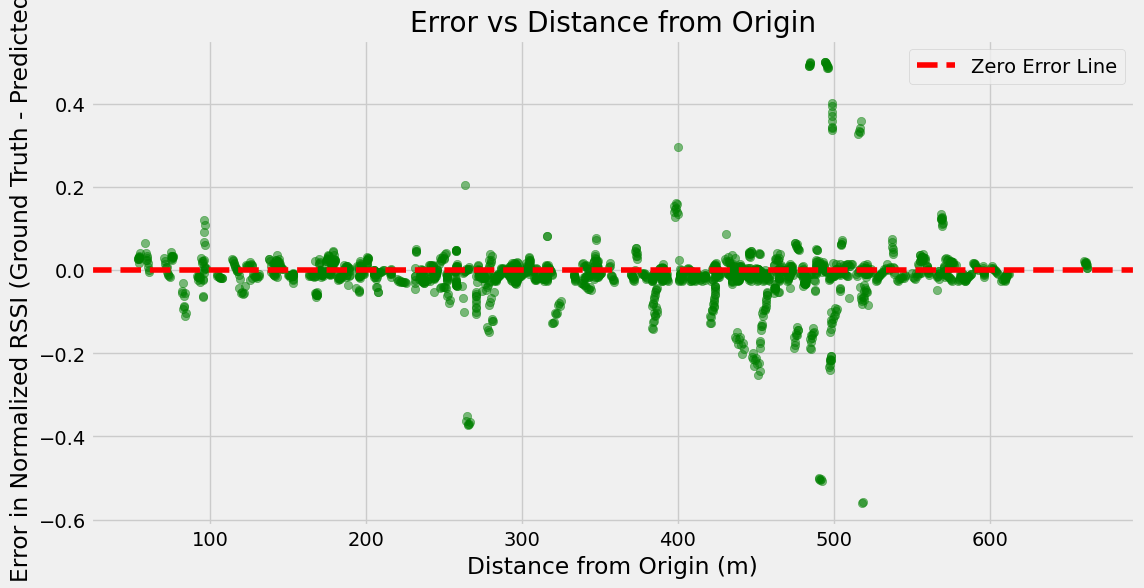

In [21]:
# Compute MSE (Lower is better)

mse = mean_squared_error(rssi_ground_truth[0], rssi_predicted[0])
mae = mean_absolute_error(rssi_ground_truth[0], rssi_predicted[0])


time = np.arange(0, 20)
index = 18
plt.figure(figsize=(12, 6))
plt.scatter(time[9:19], rssi_ground_truth[0][index, :], label='Ground Truth RSSI', color='blue', alpha=0.5)
plt.scatter(time[9:19], rssi_predicted[0][index, :], label='Predicted RSSI', color='red', alpha=0.5)
plt.scatter(time[9:19], naive_pred[index, :], label='Naive Pred', color='green', alpha=0.5)
plt.scatter(time[9:19], linear_pred[index, :], label='Predictions', color='green', alpha=0.5)
# plt.scatter(time[10:], spline_pred[index, :], label='Predictions', color='green', alpha=0.5)
plt.scatter(time[:9], rssi_seq_start[index,:9], label='Starting Seq', color='purple', alpha=0.5)
plt.title('Ground Truth vs Predicted RSSI')
plt.xlabel('Distance from Origin (m)')
plt.ylabel('Normalized RSSI')
plt.legend()
plt.grid(True)
plt.show()

#Unnormalize the data
from data_manipulations import denormalize
min_rss = -90
max_rss = 0

print(f"RNN Predictions")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

mse = mean_squared_error(rssi_ground_truth[0], linear_pred)
mae = mean_absolute_error(rssi_ground_truth[0], linear_pred)
print(f"Linear Regression Predictions")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

print(pos[0].reshape(-1, 3).shape)
print(rssi_ground_truth[0].reshape(-1).shape)

distance = torch.norm(pos[0].reshape(-1, 3), dim=1)
rssi_ground_truth_flat = np.array(rssi_ground_truth[0]).flatten()
rssi_predicted_flat = np.array(rssi_predicted[0]).flatten()

# rssi_ground_truth_flat = denormalize(rssi_ground_truth_flat, min_rss, max_rss)
# linear_pred = denormalize(linear_pred, min_rss, max_rss)
# rssi_predicted_flat = denormalize(rssi_predicted_flat, min_rss, max_rss)

# Plotting the ground truth vs predicted RSSI values
plt.figure(figsize=(12, 6))
plt.scatter(distance.numpy()[::], rssi_ground_truth_flat[::], label='Ground Truth RSSI', color='blue', alpha=0.5)
plt.scatter(distance.numpy()[::], rssi_predicted_flat[::], label='Predicted RSSI', color='red', alpha=0.5)
plt.scatter(distance.numpy()[:], np.array(linear_pred).flatten()[:], label='Linear Regression RSSI', color='green', alpha=0.5)
plt.title('Ground Truth vs Predicted RSSI')
plt.xlabel('Distance from Origin (m)')
plt.ylabel('Normalized RSSI')
plt.legend()
plt.grid(True)
plt.show()
# # Plotting the error distribution
# plt.figure(figsize=(12, 6))
# errors = np.array(rssi_ground_truth[0]).flatten() - np.array(rssi_predicted[0]).flatten()
# plt.hist(errors, bins=50, color='purple', alpha=0.7)
# errors_reg = np.array(rssi_ground_truth[0]).flatten() - linear_pred.flatten()
# plt.hist(errors_reg, bins=50, color='green', alpha=0.5)
# plt.title('Error Distribution (Ground Truth - Predicted RSSI)')
# plt.xlabel('Error in Normalized RSSI')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()
# Flatten and compute errors
errors_rnn = rssi_ground_truth_flat - rssi_predicted_flat
errors_linear = rssi_ground_truth_flat - linear_pred.flatten()
# 1. Find shared min/max
combined = np.concatenate([errors_rnn, errors_linear])
bin_edges = np.linspace(combined.min(), combined.max(), 51)  # 50 bins
# 2. Plot both with same bins
plt.figure(figsize=(12, 6))
plt.hist(errors_rnn, bins=bin_edges, color='purple', alpha=0.6, label='RNN Error')
plt.hist(errors_linear, bins=bin_edges, color='green', alpha=0.6, label='Linear Fit Error')
plt.title('Error Distribution (Ground Truth - Predicted RSSI)')
plt.xlabel('Error in Normalized RSSI')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.show()
# Plotting the error against distance
plt.figure(figsize=(12, 6))
plt.scatter(distance.numpy(), errors_rnn, color='green', alpha=0.5)
plt.title('Error vs Distance from Origin')
plt.xlabel('Distance from Origin (m)')
plt.ylabel('Error in Normalized RSSI (Ground Truth - Predicted)')
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.legend()
plt.grid(True)
plt.show()

# RNN Predictions
# Mean Squared Error (MSE): 0.0397
# Mean Absolute Error (MAE): 0.1274
# Linear Regression Predictions
# Mean Squared Error (MSE): 0.1162
# Mean Absolute Error (MAE): 0.1790

# RNN Predictions
# Mean Squared Error (MSE): 0.0264
# Mean Absolute Error (MAE): 0.1118
# Linear Regression Predictions
# Mean Squared Error (MSE): 0.0940
# Mean Absolute Error (MAE): 0.1528